In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
import numpy as np
import pandas as pd
import h5py
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from tqdm import tqdm 
from scipy import stats
from scipy.io import loadmat, savemat
from pathlib import Path
import glob
import cv2
import matplotlib.pyplot as plt
from importlib import reload
import gcamp_peak_utils as gp 
from IPython.display import display


/var/folders/fc/24x3k2m92bvbv7ck1v5mt3n40000gn/T/ipykernel_69044/2730252638.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [2]:
reload(gp)

<module 'gcamp_peak_utils' from '/Users/johnmarshall/Documents/Analysis/JJMezTrackAnalysis/gcamp_peak_utils.py'>

In [3]:
#for loading the CaliAliAlignment file 
def _decode_matlab_string(ds):
    arr = ds[()]
    return "".join(chr(int(x)) for x in arr.ravel())

def _decode_matlab_scalar(ds):
    return ds[()].ravel()[0].item()

def load_caliai_input_files(mat_path):
    rows = []
    with h5py.File(mat_path, "r") as f:
        top_refs = f["CaliAli_options/inter_session_alignment/input_files"][()]
        
        for i in range(top_refs.shape[0]):
            row_ref = top_refs[i, 0]
            row_ds = f[row_ref]          # 5x1 cell row
            cell_refs = row_ds[()]
            
            input_file = _decode_matlab_string(f[cell_refs[0, 0]])
            col2 = _decode_matlab_scalar(f[cell_refs[1, 0]])
            col3 = _decode_matlab_scalar(f[cell_refs[2, 0]])
            n_frames = int(_decode_matlab_scalar(f[cell_refs[3, 0]]))
            det_file = _decode_matlab_string(f[cell_refs[4, 0]])
            
            rows.append({
                "input_file": input_file,
                "col2": col2,
                "col3": col3,
                "n_frames": n_frames,
                "det_file": det_file,
            })
    
    return pd.DataFrame(rows)

def trim_behav_multidf_to_caliai_lengths(
    behav_multidf_subset,
    check_df,
    aligned_file_col="aligned_file",
    target_len_col="ms_n_frames",
):
    if target_len_col not in check_df.columns:
        raise KeyError(
            f"{target_len_col!r} not in check_df columns. "
            f"Available columns: {list(check_df.columns)}"
        )

    target_lengths = (
        check_df[[aligned_file_col, target_len_col]]
        .dropna(subset=[target_len_col])
        .assign(**{target_len_col: lambda df: df[target_len_col].astype(int)})
        .drop_duplicates(subset=[aligned_file_col])
        .set_index(aligned_file_col)[target_len_col]
    )

    trimmed_parts = []
    summary_rows = []

    outer_files = behav_multidf_subset.index.get_level_values(0).unique()

    for aligned_file in outer_files:
        session_df = behav_multidf_subset.loc[aligned_file]
        current_n = len(session_df)

        if aligned_file not in target_lengths.index:
            summary_rows.append({
                "aligned_file": aligned_file,
                "original_rows": current_n,
                "target_rows": None,
                "rows_removed": None,
                "status": "missing_target_length",
            })
            continue

        target_n = int(target_lengths.loc[aligned_file])

        if current_n < target_n:
            summary_rows.append({
                "aligned_file": aligned_file,
                "original_rows": current_n,
                "target_rows": target_n,
                "rows_removed": None,
                "status": "current_shorter_than_target",
            })
            continue

        trimmed_df = session_df.iloc[:target_n].copy()
        trimmed_parts.append((aligned_file, trimmed_df))

        summary_rows.append({
            "aligned_file": aligned_file,
            "original_rows": current_n,
            "target_rows": target_n,
            "rows_removed": current_n - target_n,
            "status": "trimmed" if current_n > target_n else "unchanged",
        })

    if trimmed_parts:
        trimmed_multidf = pd.concat(
            [df for _, df in trimmed_parts],
            keys=[name for name, _ in trimmed_parts],
            names=behav_multidf_subset.index.names,
        )
    else:

        trimmed_multidf = behav_multidf_subset.copy()

    trim_summary_df = pd.DataFrame(summary_rows)
    return trimmed_multidf, trim_summary_df


In [4]:
## load and do some preprocessing on the CNMFE traces 
def normalize(trace, percentile=True):
    """ Normalize a fluorescence trace by its max or its 99th percentile. """
    trace = trace - np.min(trace)
    if np.percentile(trace, 99) > 0:
        if percentile:
            trace = trace / np.percentile(trace, 99)
        else:
            trace = trace / np.max(trace)
    return trace

def load_and_filter_traces(extract_mat_path: str,
                           labels_mat_path: str,
                           label_key: str = 'labels_ex'
                          ) -> pd.DataFrame:
    """
    Load temporal_weights from extract_mat_path (v7.3) and one of the
    labels_* arrays from labels_mat_path, keep only columns where
    labels == 1, and return as a pandas DataFrame.

    Parameters
    ----------
    extract_mat_path : str
        Path to the v7.3 .mat file containing an 'output/temporal_weights' dataset.
    labels_mat_path : str
        Path to the .mat file (v7.3 or earlier) containing a 'labels' group/struct.
    label_key : str, optional
        Which labels field to use: one of 'labels_ex', 'labels_ml', or
        'labels_overall'. Default is 'labels_ex'.

    Returns
    -------
    pd.DataFrame
        Rows = frames, columns = kept cells (named 'cell_<original_index>').
    """
    # validate choice
    allowed = ('labels_ex','labels_ml','labels_overall')
    if label_key not in allowed:
        raise ValueError(f"label_key must be one of {allowed}, got '{label_key}'")

    # 1) load & transpose temporal_weights → shape (nFrames, nCells)
    with h5py.File(extract_mat_path, 'r') as f:
        tw = f['output']['temporal_weights'][()]  # often (nCells, nFrames)
    tw = np.asarray(tw).T

    # 2) try to load chosen labels via HDF5; if that fails, fall back to loadmat
    try:
        with h5py.File(labels_mat_path, 'r') as f:
            hl = f['labels'][label_key][()]
    except OSError:
        mat = loadmat(labels_mat_path,
                      struct_as_record=False,
                      squeeze_me=True)
        lbl = mat['labels']  # either a dict or a mat_struct
        # pull out the right attribute/key
        if isinstance(lbl, dict):
            hl = lbl[label_key]
        else:
            hl = getattr(lbl, label_key)

    # 3) shape‐check & squeeze
    hl = np.asarray(hl).squeeze()
    if tw.shape[1] != hl.size:
        raise ValueError(
            f"dimension mismatch: temporal_weights is {tw.shape}, "
            f"labels array '{label_key}' has length {hl.size}"
        )

    # 4) filter & build DataFrame
    mask    = (hl == 1)
    kept_i  = np.nonzero(mask)[0]
    filtered = tw[:, mask]
    cols    = [f'cell_{i}' for i in kept_i]

    return (pd.DataFrame(filtered, columns=cols), hl)

def print_h5_tree(name, obj):
    """
    Callback for h5py.File.visititems.
    Prints group/dataset name and, for datasets, its shape and dtype.
    """
    if isinstance(obj, h5py.Group):
        print(f"Group:   {name}/")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}  — shape={obj.shape}, dtype={obj.dtype}")

    
def zScoreTraces(dirPath, CNMFE_real_cells, miniscopeFramesPerSecond):
    
    CNMFE_real_cells = CNMFE_real_cells.apply(pd.to_numeric, errors='coerce')
    C_normalized = CNMFE_real_cells.apply(lambda col: normalize(col), axis=0)
    C_z_scored = CNMFE_real_cells.apply(stats.zscore).set_index(pd.to_timedelta(np.linspace(0, (len(CNMFE_real_cells)-1)*(1/miniscopeFramesPerSecond), len(CNMFE_real_cells)), unit='s'), drop=True)
    C_normalized_z_scored = C_normalized.apply(stats.zscore).set_index(pd.to_timedelta(np.linspace(0, (len(C_normalized)-1)*(1/miniscopeFramesPerSecond), len(C_normalized)), unit='s'), drop=True)

    ##load spatial components by session
    # for v4 dimensions are 600x600 pixels
 
    C_normalized_z_scored.to_csv(dirPath+'_C_traces_filtered_origHz.csv')
    
    print('finished, saved:')
    print(dirPath+'_C_traces_filtered_origHz.csv')
    
    return(C_normalized_z_scored)

def zScoreTraces_withGappedTime(dirPath, CNMFE_real_cells, miniscopeFramesPerSecond, idxsList):
    # Convert all columns to numeric (as before)
    CNMFE_real_cells = CNMFE_real_cells.apply(pd.to_numeric, errors='coerce')
    # 1) Build a list of *all* original frame‐numbers (0…N−1),
    #    then remove the “excised” ranges to get `kept_frames`.
    #    N = M + total_removed
    removed_indices = []
    for start, end in idxsList:
        # remove [start, end) from original
        removed_indices.extend(range(start, end))
    removed_set = set(removed_indices)
    # total frames originally = len(kept) + len(removed)
    total_original_frames = len(CNMFE_real_cells) + len(removed_set)
    # generate all original indices 0…N−1
    all_indices = np.arange(total_original_frames)
    # keep only those not in removed_set, in sorted order
    kept_frames = np.array([i for i in all_indices if i not in removed_set])
    # sanity‐check: kept_frames.size == len(CNMFE_real_cells)
    if kept_frames.shape[0] != len(CNMFE_real_cells):
        raise ValueError(
            "Number of kept frames (%d) != number of rows in CNMFE_real_cells (%d)"
            % (kept_frames.shape[0], len(CNMFE_real_cells))
        )
    # 2) Create a "gapped" timedelta index from those kept_frames:
    #    time (in seconds) = frame_number * (1 / samplingRate)
    times_sec = kept_frames * (1.0 / miniscopeFramesPerSecond)
    time_index = pd.to_timedelta(times_sec, unit='s')
    # 3) Now normalize & z‐score (unchanged from before), but *do not* set the index yet:
    C_normalized = CNMFE_real_cells.apply(lambda col: (col - col.min()) / (col.max() - col.min()), axis=0)
    C_z_scored   = CNMFE_real_cells.apply(stats.zscore, axis=0)
    C_norm_z     = C_normalized.apply(stats.zscore, axis=0)
    # 4) Finally, assign our custom `time_index` to both:
    C_z_scored.index   = time_index
    C_norm_z.index     = time_index
    # 5) (Optional) save to CSV
    C_norm_z.to_csv(dirPath + '_C_traces_filtered_origHz.csv')
    print("Finished, saved to:", dirPath + '_C_traces_filtered_origHz.csv')
    return C_norm_z, C_z_scored

In [5]:

def load_labels_struct(labels_mat_path):
    try:
        with h5py.File(labels_mat_path, 'r') as f:
            g = f['labels']
            out = {}
            for k in ['labels_ex', 'labels_ml', 'labels_overall']:
                out[k] = np.asarray(g[k][()]).squeeze().astype(np.int16)
            return out
    except OSError:
        mat = loadmat(labels_mat_path, struct_as_record=False, squeeze_me=True)
        lbl = mat['labels']
        out = {}
        for k in ['labels_ex', 'labels_ml', 'labels_overall']:
            out[k] = np.asarray(getattr(lbl, k)).squeeze().astype(np.int16)
        return out


def merge_human_labels(labels_ex_a, labels_ex_b):
    if labels_ex_a.shape != labels_ex_b.shape:
        raise ValueError(f"Shape mismatch: {labels_ex_a.shape} vs {labels_ex_b.shape}")

    merged = np.zeros_like(labels_ex_a, dtype=np.int16)
    merged[(labels_ex_a == -1) | (labels_ex_b == -1)] = -1
    merged[(merged == 0) & ((labels_ex_a == 1) | (labels_ex_b == 1))] = 1
    return merged


def recompute_overall(merged_labels_ex, labels_ml):
    if merged_labels_ex.shape != labels_ml.shape:
        raise ValueError(f"Shape mismatch: {merged_labels_ex.shape} vs {labels_ml.shape}")

    labels_overall = labels_ml.astype(np.int16).copy()
    human_labeled = merged_labels_ex != 0
    labels_overall[human_labeled] = merged_labels_ex[human_labeled]
    return labels_overall


In [6]:
# for calculating event rate 

def binarize_traces(df, threshold):
    """
    Return a copy of df where every value < threshold becomes 0,
    and every value >= threshold becomes 1.
    """
    return (df >= threshold).astype(int)

def suprathreshold_to_events(binary_series):
    b = np.asarray(binary_series).astype(int)
    # rising edges: 0->1 transitions
    events = (b == 1) & (np.r_[0, b[:-1]] == 0)
    return events.astype(int)

def get_event_rate(df, samplingRate):
    """
    Given a binarized DataFrame `df` of shape (n_frames, n_cells),
    compute, for each cell (column), the number of “events” in each
    forward-looking 1-second window. Returns a DataFrame of shape
    (n_frames - samplingRate + 1, n_cells).
    """
    # 1) grab the raw values (frames × cells)
    arr = df.values.astype(int)  
    # 2) build a “boxcar” kernel of length = samples per second
    kernel = np.ones(samplingRate, dtype=int)
    # 3) convolve along the time-axis for each cell (axis=0)
    #    mode='valid' gives you only positions where the full window fits
    rates = np.apply_along_axis(
        lambda col: np.convolve(col, kernel, mode='valid'),
        axis=0,
        arr=arr
    )
    # 4) build a new index so that row i corresponds to window df.index[i : i+samplingRate]
    #    if your original df.index is RangeIndex starting at 0, this is simply 0..n-sR
    new_index = df.index[: rates.shape[0]]
    return pd.DataFrame(rates, index=new_index, columns=df.columns)

def get_event_rate_same_length(df, samplingRate, pad_value=0):
    """
    Forward-looking 1-second (samplingRate-frame) window sums,
    same behavior as your mode='valid' version, but returns length == len(df)
    by padding the END with pad_value before convolution.
    """
    arr = df.to_numpy(dtype=int)
    kernel = np.ones(samplingRate, dtype=int)

    # pad the end so that 'valid' produces N outputs
    pad = samplingRate - 1
    arr_pad = np.pad(arr, ((0, pad), (0, 0)), mode='constant', constant_values=pad_value)

    rates = np.apply_along_axis(lambda col: np.convolve(col, kernel, mode='valid'), axis=0, arr=arr_pad)
    return pd.DataFrame(rates, index=df.index, columns=df.columns)

In [7]:
# velocity analysis on the behavior data 

def add_velocity_from_xy(
    df,
    cmPerPixel,
    x_col="X_coor",
    y_col="Y_coor",
    timestamp_col=None,
    sampling_period_s=None,
    downsample_rules=("100ms", "200ms"),
    median_filter_velocity=False,
    median_filter_window_samples=None,
    spatial_filter_velocity=False,
    spatial_filter_distance_cm=1.0,
    spatial_filter_future_window_s=1.0,
):
    """
    Add Distance (cm) and Velocity (cm/s) from X/Y coordinates.

    Optional post-processing:
    - median filter on velocity
    - spatial filter: if centroid does not move more than
      spatial_filter_distance_cm at any point over the next
      spatial_filter_future_window_s seconds, set velocity to 0
      for that frame.
    """
    def _future_displacement_keep_mask(
        x_vals,
        y_vals,
        cm_per_pixel,
        timestamp_ms=None,
        sampling_period=None,
        future_window_s=1.0,
        threshold_cm=1.0,
    ):
        x_vals = np.asarray(x_vals, dtype=float)
        y_vals = np.asarray(y_vals, dtype=float)
        n = len(x_vals)
        keep = np.zeros(n, dtype=bool)

        if timestamp_ms is not None:
            t_vals = pd.to_numeric(pd.Series(timestamp_ms), errors="coerce").to_numpy(dtype=float)
            window_ms = future_window_s * 1000.0

            for i in range(n):
                if np.isnan(x_vals[i]) or np.isnan(y_vals[i]) or np.isnan(t_vals[i]):
                    continue

                j_end = np.searchsorted(t_vals, t_vals[i] + window_ms, side="right")
                if j_end <= i + 1:
                    continue

                dx = x_vals[i + 1:j_end] - x_vals[i]
                dy = y_vals[i + 1:j_end] - y_vals[i]
                valid = ~(np.isnan(dx) | np.isnan(dy))
                if not valid.any():
                    continue

                max_disp_cm = np.sqrt(dx[valid] ** 2 + dy[valid] ** 2).max() * cm_per_pixel
                keep[i] = max_disp_cm > threshold_cm

        else:
            if sampling_period is None:
                raise ValueError("Provide timestamp_ms or sampling_period for spatial filter")

            future_window_samples = max(1, int(np.ceil(future_window_s / sampling_period)))

            for i in range(n):
                if np.isnan(x_vals[i]) or np.isnan(y_vals[i]):
                    continue

                j_end = min(n, i + 1 + future_window_samples)
                if j_end <= i + 1:
                    continue

                dx = x_vals[i + 1:j_end] - x_vals[i]
                dy = y_vals[i + 1:j_end] - y_vals[i]
                valid = ~(np.isnan(dx) | np.isnan(dy))
                if not valid.any():
                    continue

                max_disp_cm = np.sqrt(dx[valid] ** 2 + dy[valid] ** 2).max() * cm_per_pixel
                keep[i] = max_disp_cm > threshold_cm

        return keep

    def _apply_spatial_filter(
        velocity_series,
        x_vals,
        y_vals,
        cm_per_pixel,
        timestamp_ms=None,
        sampling_period=None,
        future_window_s=1.0,
        threshold_cm=1.0,
    ):
        keep = _future_displacement_keep_mask(
            x_vals=x_vals,
            y_vals=y_vals,
            cm_per_pixel=cm_per_pixel,
            timestamp_ms=timestamp_ms,
            sampling_period=sampling_period,
            future_window_s=future_window_s,
            threshold_cm=threshold_cm,
        )

        out_vel = velocity_series.astype(float).copy()
        out_vel[(~keep) & out_vel.notna()] = 0.0
        return out_vel

    out = df.copy()

    dx = out[x_col].diff()
    dy = out[y_col].diff()

    step_distance_px = np.sqrt(dx**2 + dy**2)
    out["Distance"] = step_distance_px * cmPerPixel

    if timestamp_col is not None:
        dt_s = pd.to_numeric(out[timestamp_col], errors="coerce").diff() / 1000.0
    elif sampling_period_s is not None:
        dt_s = pd.Series(sampling_period_s, index=out.index, dtype=float)
        dt_s.iloc[0] = np.nan
    else:
        raise ValueError("Provide either timestamp_col or sampling_period_s")

    out["Velocity"] = out["Distance"] / dt_s

    velocity_source_col = "Velocity"

    if median_filter_velocity:
        if median_filter_window_samples is None:
            raise ValueError("Provide median_filter_window_samples when median_filter_velocity=True")
        out["Velocity_filtered"] = (
            out["Velocity"]
            .rolling(window=median_filter_window_samples, center=True, min_periods=1)
            .median()
        )
        velocity_source_col = "Velocity_filtered"

    if spatial_filter_velocity:
        out["Velocity_spatial_filtered"] = _apply_spatial_filter(
            velocity_series=out[velocity_source_col],
            x_vals=out[x_col],
            y_vals=out[y_col],
            cm_per_pixel=cmPerPixel,
            timestamp_ms=out[timestamp_col] if timestamp_col is not None else None,
            sampling_period=sampling_period_s if timestamp_col is None else None,
            future_window_s=spatial_filter_future_window_s,
            threshold_cm=spatial_filter_distance_cm,
        )

    if timestamp_col is not None:
        td_index = pd.to_timedelta(pd.to_numeric(out[timestamp_col], errors="coerce"), unit="ms")
    else:
        td_index = pd.to_timedelta(np.arange(len(out)) * sampling_period_s, unit="s")

    out_td = out.set_index(td_index, drop=False)

    downsampled = {}
    for rule in downsample_rules:
        ds = out_td.resample(rule).bfill()
        ds[[x_col, y_col]] = out_td[[x_col, y_col]].resample(rule).mean()

        dx_ds = ds[x_col].diff()
        dy_ds = ds[y_col].diff()
        ds["Distance"] = np.sqrt(dx_ds**2 + dy_ds**2) * cmPerPixel

        sampling_s = pd.to_timedelta(rule).total_seconds()
        ds["Velocity"] = ds["Distance"] / sampling_s

        ds_velocity_source_col = "Velocity"

        if median_filter_velocity:
            ds["Velocity_filtered"] = (
                ds["Velocity"]
                .rolling(window=median_filter_window_samples, center=True, min_periods=1)
                .median()
            )
            ds_velocity_source_col = "Velocity_filtered"

        if spatial_filter_velocity:
            ds["Velocity_spatial_filtered"] = _apply_spatial_filter(
                velocity_series=ds[ds_velocity_source_col],
                x_vals=ds[x_col],
                y_vals=ds[y_col],
                cm_per_pixel=cmPerPixel,
                sampling_period=sampling_s,
                future_window_s=spatial_filter_future_window_s,
                threshold_cm=spatial_filter_distance_cm,
            )

        downsampled[rule] = ds

    return out, downsampled

## event rate by speed bins 

def avg_event_rate_by_speed_bins(df, idx_by_bin, speed_col='linearSpeedcmPerSecond'):
    """
    Given:
      • df            : DataFrame with one column per cell (instantaneous rates)
                        plus a `speed_col`.
      • idx_by_bin    : dict mapping (low, high) tuples → list of row-indices
                        where speed ∈ [low, high) (or >= low if high is inf).
      • speed_col     : name of the speed column in df (will be dropped).
    Returns:
      • avg_df        : DataFrame indexed by your (low, high) bins,
                        columns are the cell-names, entries are the mean
                        event-rate of that cell over all frames in that bin.
    """
    # 1) Identify all “cell” columns (everything except the speed column)
    event_cols = [c for c in df.columns if c != speed_col]

    # 2) Make a DataFrame to hold means; use a MultiIndex of your bin tuples
    bin_index = pd.MultiIndex.from_tuples(idx_by_bin.keys(), names=['low','high'])
    avg_df = pd.DataFrame(index=bin_index, columns=event_cols, dtype=float)

    # 3) For each bin, pull those rows and take the column‐wise mean
    for bin_range, idxs in idx_by_bin.items():
        if len(idxs)>0:
            avg_df.loc[bin_range] = df.loc[idxs, event_cols].mean()
        else:
            avg_df.loc[bin_range] = np.nan

    return avg_df


In [8]:
# velocity validation videos 

def create_velocity_validation_videos(
    tracking_dir,
    gcamp_df,
    source_col="ezTrackOutput",
    frame_col="closestBehavCamFrameIdx",
    x_col="X_coor",
    y_col="Y_coor",
    velocity_col="Velocity",
    output_dir=None,
    text_mode="pad_right",   # "pad_right" or "overlay"
    pad_width=240,
    codec="MJPG",
    marker_size=18,
    marker_thickness=2,
    font_scale=0.65,
    text_thickness=2,
):
    tracking_dir = Path(tracking_dir)
    output_dir = Path(output_dir) if output_dir is not None else tracking_dir / "velocity_validation_videos"
    output_dir.mkdir(parents=True, exist_ok=True)

    if text_mode not in {"pad_right", "overlay"}:
        raise ValueError("text_mode must be 'pad_right' or 'overlay'")

    def unique_path(path):
        path = Path(path)
        if not path.exists():
            return path
        k = 2
        while True:
            candidate = path.with_name(f"{path.stem}_v{k}{path.suffix}")
            if not candidate.exists():
                return candidate
            k += 1

    results = []

    grouped = gcamp_df.groupby(source_col, dropna=False)

    for eztrack_src, grp in tqdm(grouped, total=gcamp_df[source_col].nunique(), desc="Velocity validation videos"):
        if pd.isna(eztrack_src):
            continue

        csv_name = Path(str(eztrack_src)).name
        video_name = csv_name.replace("_LocationOutput.csv", ".avi")
        input_vid = tracking_dir / video_name

        if not input_vid.exists():
            results.append({
                "ezTrackOutput": eztrack_src,
                "video_path": str(input_vid),
                "output_path": None,
                "status": "missing_video",
            })
            continue

        overlay = (
            grp[[frame_col, x_col, y_col, velocity_col]]
            .dropna(subset=[frame_col])
            .assign(**{frame_col: lambda d: d[frame_col].astype(int)})
            .groupby(frame_col, as_index=True)
            .agg({
                x_col: "mean",
                y_col: "mean",
                velocity_col: "mean",
            })
            .sort_index()
        )

        cap = cv2.VideoCapture(str(input_vid))
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        overlay = overlay.reindex(range(n_frames))

        suffix = "_velocity_validation_padded.avi" if text_mode == "pad_right" else "_velocity_validation_overlay.avi"
        output_vid = unique_path(output_dir / video_name.replace(".avi", suffix))

        out_w = w + pad_width if text_mode == "pad_right" else w
        out_h = h

        fourcc = cv2.VideoWriter_fourcc(*codec)
        writer = cv2.VideoWriter(str(output_vid), fourcc, fps, (out_w, out_h), True)

        font = cv2.FONT_HERSHEY_SIMPLEX
        margin = 12
        line_gap = 28

        for frame_idx in range(n_frames):
            ret, frame = cap.read()
            if not ret:
                break

            if frame.ndim == 2:
                frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

            x_val = overlay.iloc[frame_idx][x_col]
            y_val = overlay.iloc[frame_idx][y_col]
            vel_val = overlay.iloc[frame_idx][velocity_col]

            if text_mode == "pad_right":
                canvas = np.zeros((h, out_w, 3), dtype=np.uint8)
                canvas[:, :w] = frame
            else:
                canvas = frame.copy()

            if pd.notna(x_val) and pd.notna(y_val):
                xm = int(np.clip(round(x_val), 0, w - 1))
                ym = int(np.clip(round(y_val), 0, h - 1))
                cv2.drawMarker(
                    canvas,
                    (xm, ym),
                    (255, 255, 255),
                    markerType=cv2.MARKER_TILTED_CROSS,
                    markerSize=marker_size,
                    thickness=marker_thickness,
                    line_type=cv2.LINE_AA,
                )

            line1 = f"Vel: {vel_val:.2f} cm/s" if pd.notna(vel_val) else "Vel: nan"
            line2 = f"X: {x_val:.1f} px" if pd.notna(x_val) else "X: nan"
            line3 = f"Y: {y_val:.1f} px" if pd.notna(y_val) else "Y: nan"

            if text_mode == "pad_right":
                text_x = w + margin
                text_y = margin + 20
            else:
                widths = [cv2.getTextSize(t, font, font_scale, text_thickness)[0][0] for t in (line1, line2, line3)]
                text_x = max(margin, w - max(widths) - margin)
                text_y = margin + 20

            for i, text in enumerate((line1, line2, line3)):
                y_text = text_y + i * line_gap
                if text_mode == "overlay":
                    cv2.putText(
                        canvas, text, (text_x, y_text), font, font_scale,
                        (0, 0, 0), text_thickness + 2, cv2.LINE_AA
                    )
                cv2.putText(
                    canvas, text, (text_x, y_text), font, font_scale,
                    (255, 255, 255), text_thickness, cv2.LINE_AA
                )

            writer.write(canvas)

        cap.release()
        writer.release()

        results.append({
            "ezTrackOutput": eztrack_src,
            "video_path": str(input_vid),
            "output_path": str(output_vid),
            "text_mode": text_mode,
            "status": "ok",
        })

    return pd.DataFrame(results)



In [11]:
#calcium analysis data - extract and ActSort labels 
dirPath = '/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/20260505_125714_389/'
GCaMPData_EXTRACT_fName = r'gray_denoised_converted_concat_ds_mc_Aligned_20260505_125714_389.mat'
ActSortLabels_fName = r'precomputed_output_LABELS.mat'
#have two label files here, need to merge 
#ActSortLabels_fName_0 = r'precomputed_output_LABELS.mat'
#ActSortLabels_fName_1 = r'precomputed_output_LABELS_0.mat'

In [10]:
# if needed to merge labels 
merged_out_name = 'precomputed_output_LABELS_merged.mat'

labels_path_0 = str(Path(dirPath) / ActSortLabels_fName_0)
labels_path_1 = str(Path(dirPath) / ActSortLabels_fName_1)
merged_out_path = str(Path(dirPath) / merged_out_name)
L0 = load_labels_struct(labels_path_0)
L1 = load_labels_struct(labels_path_1)
merged_labels_ex = merge_human_labels(L0['labels_ex'], L1['labels_ex'])
# use model labels from the first file by default
# if you want, you can check they are identical before trusting this
if not np.array_equal(L0['labels_ml'], L1['labels_ml']):
    print("Warning: labels_ml differs between files; using labels_ml from first file.")
merged_labels_ml = L0['labels_ml'].copy()
merged_labels_overall = recompute_overall(merged_labels_ex, merged_labels_ml)
merged_labels = {
    'labels_ex': merged_labels_ex,
    'labels_ml': merged_labels_ml,
    'labels_overall': merged_labels_overall,
}
savemat(merged_out_path, {'labels': merged_labels}, do_compression=True)
print("Saved merged labels to:", merged_out_path)
print("Merged counts:")
print("labels_ex  good:", np.sum(merged_labels_ex == 1),
      "bad:", np.sum(merged_labels_ex == -1),
      "unlabeled:", np.sum(merged_labels_ex == 0))
print("labels_overall good:", np.sum(merged_labels_overall == 1),
      "bad:", np.sum(merged_labels_overall == -1))
ActSortLabels_fName = merged_out_name

NameError: name 'ActSortLabels_fName_0' is not defined

In [12]:
#'labels_ex', 'labels_ml', or 'labels_overall'. Default is 'labels_ex'
GCAMP_traces_humanSorted, labels_human = load_and_filter_traces(dirPath+GCaMPData_EXTRACT_fName, dirPath+ActSortLabels_fName, 'labels_ex')
print('traces loaded: human labels')
GCAMP_traces_modelSorted, labels_model = load_and_filter_traces(dirPath+GCaMPData_EXTRACT_fName, dirPath+ActSortLabels_fName, 'labels_ml')
print('traces loaded: ML labels')
GCAMP_traces_OvrallSorted, labels_overall = load_and_filter_traces(dirPath+GCaMPData_EXTRACT_fName, dirPath+ActSortLabels_fName, 'labels_overall')
print('traces loaded')

traces loaded: human labels
traces loaded: ML labels
traces loaded


In [13]:
np.shape(labels_human)

(685,)

In [14]:
np.shape(labels_model)

(685,)

In [15]:
np.shape(GCAMP_traces_OvrallSorted)

(247698, 601)

In [17]:
# if data was "removed" from the calcium signals for the EXTRACT video add that information here, if no data was removed leave as empty list
# videosRemoved = [] 
videosRemoved = []; 
videoLength = 1000; 
# video 1 would 0:1000, 
idxsList=[((vidStart*1000)-1000,(vidStart)*1000) for vidStart in videosRemoved]

miniscopeFramesPerSecond = 20

GCAMP_traces_Zscore = zScoreTraces(dirPath, GCAMP_traces_OvrallSorted, miniscopeFramesPerSecond)
print('loaded all traces')

if len(videosRemoved)>0:
    GCAMP_traces_ZscoreNormalized_Gapped, GCAMP_traces_Zscore_Gapped  = zScoreTraces_withGappedTime(dirPath, GCAMP_traces_OvrallSorted, miniscopeFramesPerSecond, idxsList)
else: 
    GCAMP_traces_Zscore_Gapped = GCAMP_traces_Zscore
    

finished, saved:
/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/20260505_125714_389/_C_traces_filtered_origHz.csv
loaded all traces


In [18]:
#CaliAli alignment 
mat_path = Path('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/gray_denoised_converted_concat_ds_mc_Aligned.mat')
input_files_df = load_caliai_input_files(mat_path)


In [19]:
len(GCAMP_traces_Zscore_Gapped)

247698

In [21]:
#behavior analysis info 
pathToAlignedBehavData = "/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack/aligned_miniscope_to_eztrack_388/"
base = Path(pathToAlignedBehavData)

files = sorted(base.glob("*AlignedToEzTrack.csv"))

behav_multidf = pd.concat(
    [pd.read_csv(f) for f in files],
    keys=[f.name for f in files],
    names=["source_file", "row_in_file"]
)

behav_multidf.head()

Frame Number  \
source_file                                     row_in_file                 
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                       0   
                                                1                       1   
                                                2                       2   
                                                3                       3   
                                                4                       4   

                                                             Time Stamp (ms)  \
source_file                                     row_in_file                    
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                        -39   
                                                1                         17   
                                                2                         64   
                                                3                        113   
                                                4                        164   

                                                             Buffer Index  \
source_file                                     row_in_file                 
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                       0   
                                                1                       0   
                                                2                       0   
                                                3                       0   
                                                4                       0   

                                                             sys_clock_BehavCamFrame  \
source_file                                     row_in_file                            
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                                 -8   
                                                1                                 -8   
                                                2                                 57   
                                                3                                105   
                                                4                                169   

                                                             closestBehavCamFrameIdx  \
source_file                                     row_in_file                            
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                                  0   
                                                1                                  0   
                                                2                                  1   
                                                3                                  2   
                                                4                                  3   

                                                             abs_timestamp_diff_ms  \
source_file                                     row_in_file                          
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                               31   
                                                1                               25   
                                                2                                7   
                                                3                                8   
                                                4                                5   

                                                                 X_coor  \
source_file                                     row_in_file               
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0            563.946754   
                                                1            563.946754   
                                                2            563.222888   
                                                3            563.367979   
                                                4            561.812521   

                                                         

In [22]:
len(behav_multidf)

473856

In [23]:
input_files_df['input_file'].values

array(['/scratch/jma819/CaliAli_linearTrackData/388/2025_07_01_test_388_14_29_09/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_01_test_388_14_37_41/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_01_test_388_14_49_45/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_02_388_14_48_02/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_03_388_14_28_38/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_04_388_15_43_20/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_05_388_16_21_10/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_06_388_14_53_04/Denoised/gray

In [24]:
behav_multidfMiniscopeSubset = behav_multidf.loc[['02072025_14_48_02_miniscopeAlignedToEzTrack.csv', 
                                                  '03072025_14_28_38_miniscopeAlignedToEzTrack.csv',
                                                  '04072025_15_43_20_miniscopeAlignedToEzTrack.csv',
                                                  '05072025_16_21_10_miniscopeAlignedToEzTrack.csv', 
                                                  '06072025_14_53_04_miniscopeAlignedToEzTrack.csv',
                                                  '07072025_11_39_31_miniscopeAlignedToEzTrack.csv', 
                                                  '08072025_13_48_35_miniscopeAlignedToEzTrack.csv', 
                                                  '09072025_11_51_21_miniscopeAlignedToEzTrack.csv', 
                                                  '10072025_14_00_39_miniscopeAlignedToEzTrack.csv', 
                                                  '11072025_14_35_14_miniscopeAlignedToEzTrack.csv', 
                                                  ]]

In [25]:
len(behav_multidfMiniscopeSubset)

236928

In [27]:
### check that rows of outer levels of behav_multidfMiniscopeSubset match miniscope time stamps file
base_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack")
miniscope_ts_dir = base_dir / "timeStampsMiniscope_copied_388"
results = []
outer_files = behav_multidfMiniscopeSubset.index.get_level_values(0).unique()
for aligned_file in outer_files:
    # example: 01052025_19_58_29_miniscopeAlignedToEzTrack.csv
    session = aligned_file.replace("_miniscopeAlignedToEzTrack.csv", "")

    dd = session[2:4]
    mm = session[:2]
    yyyy = session[4:8]
    time_part = session[9:]  # after MMDDYYYY_

    miniscope_name = f"{yyyy}_{dd}_{mm}_388_{time_part}_timeStampsMiniscope.csv"
    miniscope_path = miniscope_ts_dir / miniscope_name

    aligned_n = len(behav_multidfMiniscopeSubset.loc[aligned_file])

    if miniscope_path.exists():
        miniscope_n = len(pd.read_csv(miniscope_path))
    else:
        miniscope_n = None

    results.append({
        "aligned_file": aligned_file,
        "miniscope_timestamp_file": miniscope_name,
        "aligned_rows": aligned_n,
        "miniscope_rows": miniscope_n,
        "match": aligned_n == miniscope_n if miniscope_n is not None else False,
        "timestamp_file_exists": miniscope_path.exists(),
    })
check_df = pd.DataFrame(results)
check_df


,aligned_file,miniscope_timestamp_file,aligned_rows,miniscope_rows,match,timestamp_file_exists
0,02072025_14_48_02_miniscopeAlignedToEzTrack.csv,2025_07_02_388_14_48_02_timeStampsMiniscope.csv,23689,23689,True,True
1,03072025_14_28_38_miniscopeAlignedToEzTrack.csv,2025_07_03_388_14_28_38_timeStampsMiniscope.csv,23695,23695,True,True
2,04072025_15_43_20_miniscopeAlignedToEzTrack.csv,2025_07_04_388_15_43_20_timeStampsMiniscope.csv,23693,23693,True,True
3,05072025_16_21_10_miniscopeAlignedToEzTrack.csv,2025_07_05_388_16_21_10_timeStampsMiniscope.csv,23691,23691,True,True
4,06072025_14_53_04_miniscopeAlignedToEzTrack.csv,2025_07_06_388_14_53_04_timeStampsMiniscope.csv,23696,23696,True,True
5,07072025_11_39_31_miniscopeAlignedToEzTrack.csv,2025_07_07_388_11_39_31_timeStampsMiniscope.csv,23693,23693,True,True
6,08072025_13_48_35_miniscopeAlignedToEzTrack.csv,2025_07_08_388_13_48_35_timeStampsMiniscope.csv,23687,23687,True,True
7,09072025_11_51_21_miniscopeAlignedToEzTrack.csv,2025_07_09_388_11_51_21_timeStampsMiniscope.csv,23693,23693,True,True
8,10072025_14_00_39_miniscopeAlignedToEzTrack.csv,2025_07_10_388_14_00_39_timeStampsMiniscope.csv,23694,23694,True,True
9,11072025_14_35_14_miniscopeAlignedToEzTrack.csv,2025_07_11_388_14_35_14_timeStampsMiniscope.csv,23697,23697,True,True


In [28]:
input_files_df['input_file'].values

array(['/scratch/jma819/CaliAli_linearTrackData/388/2025_07_01_test_388_14_29_09/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_01_test_388_14_37_41/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_01_test_388_14_49_45/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_02_388_14_48_02/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_03_388_14_28_38/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_04_388_15_43_20/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_05_388_16_21_10/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_06_388_14_53_04/Denoised/gray

In [29]:
## correct for where fewer miniscope frames per day were aligned 

input_files_df2 = input_files_df.copy()
check_df2 = check_df.copy()

session_key_pattern = r"(\d{4}_\d{2}_\d{2}_\d+_\d{2}_\d{2}_\d{2})"

input_files_df2["ms_session_key"] = (
    input_files_df2["input_file"]
    .astype(str)
    .str.extract(session_key_pattern, expand=False)
)

check_df2["ms_session_key"] = (
    check_df2["miniscope_timestamp_file"]
    .astype(str)
    .str.extract(session_key_pattern, expand=False)
)

ms_lookup = (
    input_files_df2[["ms_session_key", "input_file", "n_frames"]]
    .dropna(subset=["ms_session_key"])
    .drop_duplicates(subset=["ms_session_key"])
    .rename(columns={
        "input_file": "ms_input_file",
        "n_frames": "ms_n_frames"
    })
)

check_df_aligned = check_df2.merge(ms_lookup, on="ms_session_key", how="left")

check_df_aligned




,aligned_file,miniscope_timestamp_file,aligned_rows,miniscope_rows,match,timestamp_file_exists,ms_session_key,ms_input_file,ms_n_frames
0,02072025_14_48_02_miniscopeAlignedToEzTrack.csv,2025_07_02_388_14_48_02_timeStampsMiniscope.csv,23689,23689,True,True,2025_07_02_388_14_48_02,/scratch/jma819/CaliAli_linearTrackData/388/20...,23689
1,03072025_14_28_38_miniscopeAlignedToEzTrack.csv,2025_07_03_388_14_28_38_timeStampsMiniscope.csv,23695,23695,True,True,2025_07_03_388_14_28_38,/scratch/jma819/CaliAli_linearTrackData/388/20...,23695
2,04072025_15_43_20_miniscopeAlignedToEzTrack.csv,2025_07_04_388_15_43_20_timeStampsMiniscope.csv,23693,23693,True,True,2025_07_04_388_15_43_20,/scratch/jma819/CaliAli_linearTrackData/388/20...,23693
3,05072025_16_21_10_miniscopeAlignedToEzTrack.csv,2025_07_05_388_16_21_10_timeStampsMiniscope.csv,23691,23691,True,True,2025_07_05_388_16_21_10,/scratch/jma819/CaliAli_linearTrackData/388/20...,23691
4,06072025_14_53_04_miniscopeAlignedToEzTrack.csv,2025_07_06_388_14_53_04_timeStampsMiniscope.csv,23696,23696,True,True,2025_07_06_388_14_53_04,/scratch/jma819/CaliAli_linearTrackData/388/20...,23696
5,07072025_11_39_31_miniscopeAlignedToEzTrack.csv,2025_07_07_388_11_39_31_timeStampsMiniscope.csv,23693,23693,True,True,2025_07_07_388_11_39_31,/scratch/jma819/CaliAli_linearTrackData/388/20...,23693
6,08072025_13_48_35_miniscopeAlignedToEzTrack.csv,2025_07_08_388_13_48_35_timeStampsMiniscope.csv,23687,23687,True,True,2025_07_08_388_13_48_35,/scratch/jma819/CaliAli_linearTrackData/388/20...,23687
7,09072025_11_51_21_miniscopeAlignedToEzTrack.csv,2025_07_09_388_11_51_21_timeStampsMiniscope.csv,23693,23693,True,True,2025_07_09_388_11_51_21,/scratch/jma819/CaliAli_linearTrackData/388/20...,23693
8,10072025_14_00_39_miniscopeAlignedToEzTrack.csv,2025_07_10_388_14_00_39_timeStampsMiniscope.csv,23694,23694,True,True,2025_07_10_388_14_00_39,/scratch/jma819/CaliAli_linearTrackData/388/20...,23694
9,11072025_14_35_14_miniscopeAlignedToEzTrack.csv,2025_07_11_388_14_35_14_timeStampsMiniscope.csv,23697,23697,True,True,2025_07_11_388_14_35_14,/scratch/jma819/CaliAli_linearTrackData/388/20...,23697


In [30]:
check_df_aligned['ms_input_file'].values

array(['/scratch/jma819/CaliAli_linearTrackData/388/2025_07_02_388_14_48_02/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_03_388_14_28_38/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_04_388_15_43_20/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_05_388_16_21_10/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_06_388_14_53_04/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_07_388_11_39_31/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_08_388_13_48_35/Denoised/gray_denoised_converted_concat_ds_mc.mat',
       '/scratch/jma819/CaliAli_linearTrackData/388/2025_07_09_388_11_51_21/Denoised/gray_denoised_conve

In [31]:
behav_multidfMiniscopeSubset.head()

Frame Number  \
source_file                                     row_in_file                 
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                       0   
                                                1                       1   
                                                2                       2   
                                                3                       3   
                                                4                       4   

                                                             Time Stamp (ms)  \
source_file                                     row_in_file                    
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                        -39   
                                                1                         17   
                                                2                         64   
                                                3                        113   
                                                4                        164   

                                                             Buffer Index  \
source_file                                     row_in_file                 
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                       0   
                                                1                       0   
                                                2                       0   
                                                3                       0   
                                                4                       0   

                                                             sys_clock_BehavCamFrame  \
source_file                                     row_in_file                            
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                                 -8   
                                                1                                 -8   
                                                2                                 57   
                                                3                                105   
                                                4                                169   

                                                             closestBehavCamFrameIdx  \
source_file                                     row_in_file                            
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                                  0   
                                                1                                  0   
                                                2                                  1   
                                                3                                  2   
                                                4                                  3   

                                                             abs_timestamp_diff_ms  \
source_file                                     row_in_file                          
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0                               31   
                                                1                               25   
                                                2                                7   
                                                3                                8   
                                                4                                5   

                                                                 X_coor  \
source_file                                     row_in_file               
02072025_14_48_02_miniscopeAlignedToEzTrack.csv 0            563.946754   
                                                1            563.946754   
                                                2            563.222888   
                                                3            563.367979   
                                                4            561.812521   

                                                         

In [32]:
behav_multidfMiniscopeSubset_trimmed, trim_summary_df = trim_behav_multidf_to_caliai_lengths(
    behav_multidfMiniscopeSubset,
    check_df_aligned
)

trim_summary_df

,aligned_file,original_rows,target_rows,rows_removed,status
0,02072025_14_48_02_miniscopeAlignedToEzTrack.csv,23689,23689,0,unchanged
1,03072025_14_28_38_miniscopeAlignedToEzTrack.csv,23695,23695,0,unchanged
2,04072025_15_43_20_miniscopeAlignedToEzTrack.csv,23693,23693,0,unchanged
3,05072025_16_21_10_miniscopeAlignedToEzTrack.csv,23691,23691,0,unchanged
4,06072025_14_53_04_miniscopeAlignedToEzTrack.csv,23696,23696,0,unchanged
5,07072025_11_39_31_miniscopeAlignedToEzTrack.csv,23693,23693,0,unchanged
6,08072025_13_48_35_miniscopeAlignedToEzTrack.csv,23687,23687,0,unchanged
7,09072025_11_51_21_miniscopeAlignedToEzTrack.csv,23693,23693,0,unchanged
8,10072025_14_00_39_miniscopeAlignedToEzTrack.csv,23694,23694,0,unchanged
9,11072025_14_35_14_miniscopeAlignedToEzTrack.csv,23697,23697,0,unchanged


In [35]:
# Trim calcium rows for miniscope sessions that do NOT have corresponding behavior data
# Assumes GCAMP_traces_Zscore_Gapped is concatenated in the same session order as input_files_df2

# behavior-backed miniscope input files
behavior_input_files = set(
    check_df_aligned["ms_input_file"].dropna().astype(str).unique()
)

# session manifest in the same order used to build the calcium traces
gcamp_session_df = input_files_df2[["input_file", "n_frames"]].copy()
gcamp_session_df["input_file"] = gcamp_session_df["input_file"].astype(str)
gcamp_session_df["n_frames"] = gcamp_session_df["n_frames"].astype(int)
gcamp_session_df["has_behavior"] = gcamp_session_df["input_file"].isin(behavior_input_files)

# build row ranges for each miniscope session inside the concatenated GCAMP dataframe
frame_counts = gcamp_session_df["n_frames"].to_numpy()
start_rows = np.r_[0, np.cumsum(frame_counts[:-1])]
end_rows = np.cumsum(frame_counts)

gcamp_session_df["start_row"] = start_rows
gcamp_session_df["end_row_exclusive"] = end_rows
gcamp_session_df["rows_removed"] = np.where(
    gcamp_session_df["has_behavior"], 0, gcamp_session_df["n_frames"]
)
gcamp_session_df["status"] = np.where(
    gcamp_session_df["has_behavior"], "kept", "removed_no_behavior"
)

expected_total_rows = int(gcamp_session_df["n_frames"].sum())
actual_total_rows = len(GCAMP_traces_Zscore_Gapped)

print("Expected total rows from input_files_df2:", expected_total_rows)
print("Actual rows in GCAMP_traces_Zscore_Gapped:", actual_total_rows)

if expected_total_rows != actual_total_rows:
    raise ValueError(
        "Row-count mismatch: sum(input_files_df2['n_frames']) does not match "
        "len(GCAMP_traces_Zscore_Gapped). "
        "Check whether extra gapping/removal was applied before trimming."
    )

# keep only sessions that have matching behavior
keep_mask = np.zeros(actual_total_rows, dtype=bool)

for _, row in gcamp_session_df[gcamp_session_df["has_behavior"]].iterrows():
    keep_mask[int(row["start_row"]):int(row["end_row_exclusive"])] = True

GCAMP_traces_Zscore_Gapped_trimmed = (
    GCAMP_traces_Zscore_Gapped.iloc[keep_mask].reset_index(drop=True)
)

gcamp_trim_summary_df = gcamp_session_df[
    ["input_file", "n_frames", "start_row", "end_row_exclusive", "has_behavior", "rows_removed", "status"]
].copy()

display(gcamp_trim_summary_df)

print("Original GCAMP rows:", len(GCAMP_traces_Zscore_Gapped))
print("Trimmed GCAMP rows:", len(GCAMP_traces_Zscore_Gapped_trimmed))
print("Trimmed behavior rows:", len(behav_multidfMiniscopeSubset_trimmed))

if len(GCAMP_traces_Zscore_Gapped_trimmed) != len(behav_multidfMiniscopeSubset_trimmed):
    raise ValueError(
        "After trimming, calcium rows still do not match behavior rows."
    )

# overwrite so downstream cells can stay unchanged
GCAMP_traces_Zscore_Gapped = GCAMP_traces_Zscore_Gapped_trimmed.copy()

print("Final GCAMP_traces_Zscore_Gapped rows:", len(GCAMP_traces_Zscore_Gapped))


Expected total rows from input_files_df2: 247698
Actual rows in GCAMP_traces_Zscore_Gapped: 247698


,input_file,n_frames,start_row,end_row_exclusive,has_behavior,rows_removed,status
0,/scratch/jma819/CaliAli_linearTrackData/388/20...,3595,0,3595,False,3595,removed_no_behavior
1,/scratch/jma819/CaliAli_linearTrackData/388/20...,3591,3595,7186,False,3591,removed_no_behavior
2,/scratch/jma819/CaliAli_linearTrackData/388/20...,3584,7186,10770,False,3584,removed_no_behavior
3,/scratch/jma819/CaliAli_linearTrackData/388/20...,23689,10770,34459,True,0,kept
4,/scratch/jma819/CaliAli_linearTrackData/388/20...,23695,34459,58154,True,0,kept
5,/scratch/jma819/CaliAli_linearTrackData/388/20...,23693,58154,81847,True,0,kept
6,/scratch/jma819/CaliAli_linearTrackData/388/20...,23691,81847,105538,True,0,kept
7,/scratch/jma819/CaliAli_linearTrackData/388/20...,23696,105538,129234,True,0,kept
8,/scratch/jma819/CaliAli_linearTrackData/388/20...,23693,129234,152927,True,0,kept
9,/scratch/jma819/CaliAli_linearTrackData/388/20...,23687,152927,176614,True,0,kept


Original GCAMP rows: 247698
Trimmed GCAMP rows: 236928
Trimmed behavior rows: 236928
Final GCAMP_traces_Zscore_Gapped rows: 236928


In [36]:
len(behav_multidfMiniscopeSubset_trimmed)

236928

In [37]:
len(GCAMP_traces_Zscore_Gapped)

236928

In [38]:
# concat behavior to GCamp data 
behav_cols = (
    behav_multidfMiniscopeSubset_trimmed[["X_coor", "Y_coor", "Distance_px", "ezTrackOutput", "closestBehavCamFrameIdx"]]
    .reset_index(drop=True)
)
gcamp_df = GCAMP_traces_Zscore_Gapped.reset_index(drop=True)
GCAMP_traces_Zscore_Gapped_with_behav = pd.concat(
    [gcamp_df, behav_cols],
    axis=1
)


In [39]:
GCAMP_traces_Zscore_Gapped_with_behav.head()

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_677,cell_679,cell_682,cell_683,cell_684,X_coor,Y_coor,Distance_px,ezTrackOutput,closestBehavCamFrameIdx
0,-0.251195,0.462455,0.581306,0.205421,-0.624823,-0.481508,0.693251,0.227770,-0.398564,0.256106,...,-0.603677,-0.628560,-0.582590,0.132338,0.248241,563.946754,18.344058,0.000000,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,0
1,-0.458872,1.047271,0.151259,0.744760,-0.015778,0.134396,0.194294,-0.101236,-0.593136,-0.307557,...,1.236456,1.993721,0.175766,-0.606154,-0.603563,563.946754,18.344058,0.000000,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,0
2,0.425297,-0.593201,1.272277,0.004968,-0.624823,-0.594070,-0.538972,-0.526138,2.089577,-0.532021,...,-0.603677,-0.628560,-0.591812,-0.606154,0.219239,563.222888,17.758492,0.931059,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,1
3,-0.089072,-0.593201,0.624139,-0.430918,1.226219,0.470237,-0.538972,-0.336903,-0.593136,-0.532021,...,-0.603677,-0.628560,-0.488041,1.926230,-0.590538,563.367979,17.552872,0.251656,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,2
4,-0.458872,2.314060,-0.544513,-0.430918,0.745202,-0.560302,-0.257218,-0.526138,-0.052842,0.532170,...,-0.603677,0.074552,-0.221999,-0.606154,1.345227,561.812521,18.103598,1.650075,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,3


In [40]:
cmPerPixel = 0.22

GCAMP_with_velocity, downsampled = add_velocity_from_xy(
    GCAMP_traces_Zscore_Gapped_with_behav,
    cmPerPixel=cmPerPixel,
    sampling_period_s=0.05,
    median_filter_velocity=True,
    median_filter_window_samples=30,
    spatial_filter_velocity=True,
    spatial_filter_distance_cm=1.0,
    spatial_filter_future_window_s=2.0,
)


In [41]:
# Velocity in Cm/Sec 
GCAMP_with_velocity.head()

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_684,X_coor,Y_coor,Distance_px,ezTrackOutput,closestBehavCamFrameIdx,Distance,Velocity,Velocity_filtered,Velocity_spatial_filtered
0,-0.251195,0.462455,0.581306,0.205421,-0.624823,-0.481508,0.693251,0.227770,-0.398564,0.256106,...,0.248241,563.946754,18.344058,0.000000,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,0,NaN,NaN,3.122364,3.122364
1,-0.458872,1.047271,0.151259,0.744760,-0.015778,0.134396,0.194294,-0.101236,-0.593136,-0.307557,...,-0.603563,563.946754,18.344058,0.000000,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,0,0.000000,0.000000,3.629753,3.629753
2,0.425297,-0.593201,1.272277,0.004968,-0.624823,-0.594070,-0.538972,-0.526138,2.089577,-0.532021,...,0.219239,563.222888,17.758492,0.931059,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,1,0.204833,4.096660,3.122364,3.122364
3,-0.089072,-0.593201,0.624139,-0.430918,1.226219,0.470237,-0.538972,-0.336903,-0.593136,-0.532021,...,-0.590538,563.367979,17.552872,0.251656,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,2,0.055364,1.107286,3.629753,3.629753
4,-0.458872,2.314060,-0.544513,-0.430918,0.745202,-0.560302,-0.257218,-0.526138,-0.052842,0.532170,...,1.345227,561.812521,18.103598,1.650075,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,3,0.363017,7.260331,3.863206,3.863206


In [42]:
## pull out velocity "bin" periods 
velocity_bins = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]
velocity_bin_ilocs = {(lo, hi): np.flatnonzero(((GCAMP_with_velocity["Velocity_spatial_filtered"] >= lo) & ((GCAMP_with_velocity["Velocity_spatial_filtered"] < hi) if np.isfinite(hi) else True)).to_numpy()).tolist() for lo, hi in velocity_bins}


In [43]:
## create velocity validation videos 

validation_summary = create_velocity_validation_videos(
    tracking_dir="/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack/BehavCamConcactenated_388/rotated_and_cropped_avi",
    gcamp_df=GCAMP_with_velocity, velocity_col="Velocity_spatial_filtered"
)

Velocity validation videos: 100%|██████████████| 10/10 [11:05<00:00, 66.52s/it]


In [44]:
velocity_bin_ilocs

{(0, 0.5): [128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  158,
  159,
  160,
  161,
  352,
  715,
  716,
  717,
  718,
  719,
  720,
  721,
  722,
  723,
  910,
  911,
  912,
  913,
  914,
  915,
  916,
  917,
  918,
  919,
  920,
  921,
  946,
  947,
  948,
  949,
  950,
  951,
  952,
  953,
  954,
  955,
  956,
  957,
  958,
  959,
  1097,
  1098,
  1099,
  1100,
  1103,
  1104,
  1106,
  1107,
  1109,
  1414,
  1415,
  1416,
  1417,
  1433,
  1434,
  1486,
  1487,
  1488,
  1489,
  1490,
  1497,
  1498,
  1499,
  1500,
  1502,
  1503,
  1504,
  1505,
  1506,
  1507,
  1508,
  1509,
  1510,
  1511,
  1512,
  1513,
  1514,
  1515,
  1516,
  1517,
  1518,
  1519,
  1529,
  1530,
  1699,
  1700,
  1701,
  1851,
  1852,
  1865,
  2028,
  2029,
  2030,
  2031,
  2032,
  2033,
  2034,
  2035,
  2040,
  2048,
  2049,
  2060,
  26

In [45]:
## calculate event rate
aligned_GCAMP = GCAMP_with_velocity.loc[:, GCAMP_with_velocity.columns.str.startswith('cell_')]

In [46]:
aligned_GCAMP

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_669,cell_670,cell_673,cell_674,cell_675,cell_677,cell_679,cell_682,cell_683,cell_684
0,-0.251195,0.462455,0.581306,0.205421,-0.624823,-0.481508,0.693251,0.227770,-0.398564,0.256106,...,1.164743,-0.324098,1.027749,0.336279,-0.569397,-0.603677,-0.628560,-0.582590,0.132338,0.248241
1,-0.458872,1.047271,0.151259,0.744760,-0.015778,0.134396,0.194294,-0.101236,-0.593136,-0.307557,...,-0.620949,-0.570554,3.117723,-0.381127,-0.569397,1.236456,1.993721,0.175766,-0.606154,-0.603563
2,0.425297,-0.593201,1.272277,0.004968,-0.624823,-0.594070,-0.538972,-0.526138,2.089577,-0.532021,...,-0.620949,1.170166,-0.571845,-0.625953,-0.538581,-0.603677,-0.628560,-0.591812,-0.606154,0.219239
3,-0.089072,-0.593201,0.624139,-0.430918,1.226219,0.470237,-0.538972,-0.336903,-0.593136,-0.532021,...,-0.132747,-0.570554,-0.410847,0.197002,-0.569397,-0.603677,-0.628560,-0.488041,1.926230,-0.590538
4,-0.458872,2.314060,-0.544513,-0.430918,0.745202,-0.560302,-0.257218,-0.526138,-0.052842,0.532170,...,1.874792,-0.180908,-0.247216,-0.163447,-0.569397,-0.603677,0.074552,-0.221999,-0.606154,1.345227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236923,0.138279,-0.593201,3.024012,-0.430918,4.820004,-0.594070,0.291257,-0.381628,-0.593136,-0.532021,...,-0.620949,-0.570554,-0.571845,1.939607,-0.569397,-0.251966,-0.628560,-0.585760,-0.606154,-0.603563
236924,-0.458872,-0.593201,0.297631,-0.430918,3.931762,-0.138906,0.142042,-0.389938,-0.593136,-0.532021,...,-0.620949,-0.570554,1.630836,2.614807,-0.569397,1.022137,0.511351,-0.591812,-0.606154,1.639831
236925,-0.458872,-0.593201,1.047331,-0.430918,2.574298,-0.594070,-0.177803,-0.526138,-0.593136,0.946310,...,-0.620949,-0.570554,-0.571845,-0.625953,-0.569397,1.440565,1.021567,-0.007320,-0.606154,0.430974
236926,-0.096291,0.390700,-0.032232,-0.430918,2.730873,-0.594070,-0.538972,0.306978,-0.593136,-0.532021,...,-0.620949,1.044343,-0.571845,2.589570,-0.569397,3.326089,0.000301,-0.518115,-0.606154,0.532462


In [47]:
firingThresholdSD = 2.5
signalPeaks = binarize_traces(aligned_GCAMP, firingThresholdSD)
signalPeaksOnsets = signalPeaks.apply(suprathreshold_to_events, axis=0)

In [48]:
signalPeaksOnsets.head()

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_669,cell_670,cell_673,cell_674,cell_675,cell_677,cell_679,cell_682,cell_683,cell_684
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
# get the event rate per cell 
instantaneousEventRate = get_event_rate_same_length(signalPeaks, samplingRate=20).reset_index(drop=True)
instantaneousEventRateOnsets = get_event_rate_same_length(signalPeaksOnsets, samplingRate=20).reset_index(drop=True)

In [50]:
instantaneousEventRate["Velocity_spatial_filtered"] = GCAMP_with_velocity["Velocity_spatial_filtered"].reset_index(drop=True)
instantaneousEventRateOnsets["Velocity_spatial_filtered"] = GCAMP_with_velocity["Velocity_spatial_filtered"].reset_index(drop=True)
instantaneousEventRate['X_coor'] = GCAMP_with_velocity['X_coor'].reset_index(drop=True)
instantaneousEventRateOnsets['X_coor'] = GCAMP_with_velocity['X_coor'].reset_index(drop=True)

In [51]:
GCAMP_with_velocity.columns

Index(['cell_1', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8',
       'cell_9', 'cell_10', 'cell_11',
       ...
       'cell_684', 'X_coor', 'Y_coor', 'Distance_px', 'ezTrackOutput',
       'closestBehavCamFrameIdx', 'Distance', 'Velocity', 'Velocity_filtered',
       'Velocity_spatial_filtered'],
      dtype='object', length=610)

In [52]:
instantaneousEventRateOnsets

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_673,cell_674,cell_675,cell_677,cell_679,cell_682,cell_683,cell_684,Velocity_spatial_filtered,X_coor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,2,2,0,0,3.122364,563.946754
1,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,2,2,0,0,3.629753,563.946754
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,2,0,0,3.122364,563.222888
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,2,0,0,3.629753,563.367979
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,2,0,0,3.863206,561.812521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236923,0,0,0,0,0,0,0,0,0,0,...,0,2,0,1,0,0,0,0,0.000000,24.601668
236924,0,0,0,0,0,0,0,0,0,0,...,0,2,0,1,0,0,0,0,0.000000,22.308074
236925,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0.000000,20.910949
236926,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0.000000,20.910949


In [53]:
saveDir = Path('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388_analysis')
saveDir.mkdir(parents=True, exist_ok=True)

GCAMP_with_velocity.to_csv(saveDir / "GCAMP_with_velocity.csv", index=True)
instantaneousEventRate.to_csv(saveDir / "instantaneousEventRate.csv", index=True)
instantaneousEventRateOnsets.to_csv(saveDir / "instantaneousEventRateOnsets.csv", index=True)

In [54]:
#avg rates (all above threshold) by speed 
avg_rates = avg_event_rate_by_speed_bins(
    instantaneousEventRate,
    velocity_bin_ilocs,
    speed_col="Velocity_spatial_filtered"
)
#avg rates (onsets - rising edge ) by speed 
avg_rates_onsets = avg_event_rate_by_speed_bins(
    instantaneousEventRateOnsets,
    velocity_bin_ilocs,
    speed_col="Velocity_spatial_filtered"
)

In [55]:
instantaneousEventRate.head()

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_673,cell_674,cell_675,cell_677,cell_679,cell_682,cell_683,cell_684,Velocity_spatial_filtered,X_coor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,2,2,0,0,3.122364,563.946754
1,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,2,2,0,0,3.629753,563.946754
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,2,0,0,3.122364,563.222888
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,2,0,0,3.629753,563.367979
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,2,2,0,0,3.863206,561.812521


In [56]:
avg_rates.mean(axis=1)

low   high
0.0   0.5     1.132056
0.5   2.0     0.725025
2.0   5.0     1.168326
5.0   10.0    1.201379
10.0  inf     1.118104
dtype: float64

In [57]:
avg_rates_onsets.mean(axis=1)

low   high
0.0   0.5     0.933439
0.5   2.0     0.481219
2.0   5.0     0.947301
5.0   10.0    0.971401
10.0  inf     0.833054
dtype: float64

In [58]:
## validating peak detection - start from GCAMP_with_velocity so can load from file

In [59]:
GCAMP_with_velocity

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_684,X_coor,Y_coor,Distance_px,ezTrackOutput,closestBehavCamFrameIdx,Distance,Velocity,Velocity_filtered,Velocity_spatial_filtered
0,-0.251195,0.462455,0.581306,0.205421,-0.624823,-0.481508,0.693251,0.227770,-0.398564,0.256106,...,0.248241,563.946754,18.344058,0.000000,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,0,NaN,NaN,3.122364,3.122364
1,-0.458872,1.047271,0.151259,0.744760,-0.015778,0.134396,0.194294,-0.101236,-0.593136,-0.307557,...,-0.603563,563.946754,18.344058,0.000000,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,0,0.000000,0.000000,3.629753,3.629753
2,0.425297,-0.593201,1.272277,0.004968,-0.624823,-0.594070,-0.538972,-0.526138,2.089577,-0.532021,...,0.219239,563.222888,17.758492,0.931059,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,1,0.204833,4.096660,3.122364,3.122364
3,-0.089072,-0.593201,0.624139,-0.430918,1.226219,0.470237,-0.538972,-0.336903,-0.593136,-0.532021,...,-0.590538,563.367979,17.552872,0.251656,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,2,0.055364,1.107286,3.629753,3.629753
4,-0.458872,2.314060,-0.544513,-0.430918,0.745202,-0.560302,-0.257218,-0.526138,-0.052842,0.532170,...,1.345227,561.812521,18.103598,1.650075,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,3,0.363017,7.260331,3.863206,3.863206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236923,0.138279,-0.593201,3.024012,-0.430918,4.820004,-0.594070,0.291257,-0.381628,-0.593136,-0.532021,...,-0.603563,24.601668,19.765362,3.895802,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,20570,0.857076,17.141528,8.335048,0.000000
236924,-0.458872,-0.593201,0.297631,-0.430918,3.931762,-0.138906,0.142042,-0.389938,-0.593136,-0.532021,...,1.639831,22.308074,19.496259,2.309327,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,20571,0.508052,10.161040,7.485702,0.000000
236925,-0.458872,-0.593201,1.047331,-0.430918,2.574298,-0.594070,-0.177803,-0.526138,-0.593136,0.946310,...,0.430974,20.910949,19.683989,1.409681,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,20572,0.310130,6.202598,8.335048,0.000000
236926,-0.096291,0.390700,-0.032232,-0.430918,2.730873,-0.594070,-0.538972,0.306978,-0.593136,-0.532021,...,0.532462,20.910949,19.683989,1.409681,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,20572,0.000000,0.000000,9.184394,0.000000


In [60]:
signalPeaks = gp.detect_peaks_df(
    aligned_GCAMP,
    threshold=2.5,
    smooth_window_samples=3,
    min_peak_prominence=1.0,
    min_peak_distance_samples=15,
    min_peak_width_samples=2,
    return_to_baseline_tol=0.5,
    return_to_baseline_window_samples=4,
)

In [61]:
signalPeaks

,cell_1,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,cell_11,...,cell_669,cell_670,cell_673,cell_674,cell_675,cell_677,cell_679,cell_682,cell_683,cell_684
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236923,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
236924,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
236925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
236926,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
cell_name = 'cell_3'
stats_df = gp.compute_peak_stats_from_cell(
    signalPeaks[cell_name],
    z_scores=aligned_GCAMP[cell_name],
    cell_trace=aligned_GCAMP[cell_name],
    tol=0.25,
    window_len_onset=3,
    window_len_offset=3,
    plt_region=10,
)

stats_df[0:10]

,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end,clipped_region
0,366,256,3930,14.370664,3674,246,3940,"[0.512490451335907, 0.11521497368812561, 1.008..."
1,732,256,3930,14.370664,3674,246,3940,"[0.512490451335907, 0.11521497368812561, 1.008..."
2,981,256,3930,14.370664,3674,246,3940,"[0.512490451335907, 0.11521497368812561, 1.008..."
3,1112,995,3930,14.370664,2935,985,3940,"[0.7640745043754578, -0.11838161200284958, -0...."
4,1830,995,3930,14.370664,2935,985,3940,"[0.7640745043754578, -0.11838161200284958, -0...."
5,1875,995,3930,14.370664,2935,985,3940,"[0.7640745043754578, -0.11838161200284958, -0...."
6,2033,995,3930,14.370664,2935,985,3940,"[0.7640745043754578, -0.11838161200284958, -0...."
7,2226,2209,2250,12.358781,41,2199,2260,"[-0.5932008028030396, -0.576392650604248, 0.41..."
8,2584,2498,236927,20.315636,234429,2488,236927,"[-0.5932008028030396, -0.5932008028030396, -0...."
9,2722,2498,236927,20.315636,234429,2488,236927,"[-0.5932008028030396, -0.5932008028030396, -0...."


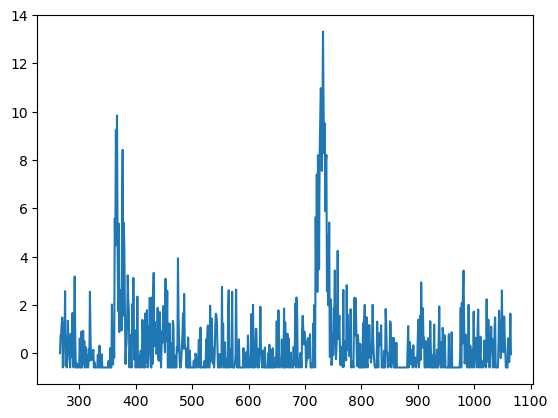

In [66]:
cell=cell_name
peak_idx=0
window=(100, 700)
plt.plot(aligned_GCAMP[cell][(stats_df.loc[peak_idx]['peak_idx']-window[0]):(stats_df.loc[peak_idx]['peak_idx']+window[1])])

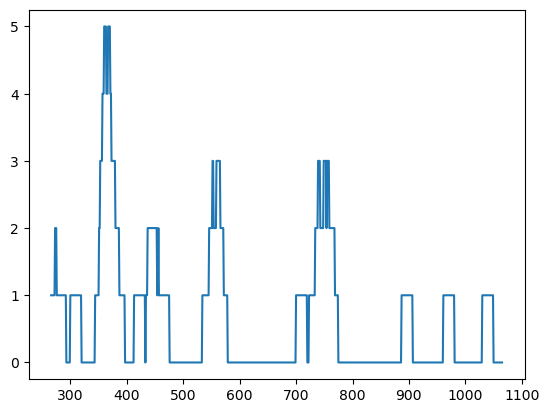

In [67]:
instantaneousEventRateOnsets[cell]
plt.plot(instantaneousEventRateOnsets[cell][(stats_df.loc[peak_idx]['peak_idx']-window[0]):(stats_df.loc[peak_idx]['peak_idx']+window[1])])

In [ ]:
cell

In [68]:
reload(gp)


cell_name = cell
peak_row = peak_idx
window_vid = (window[0], window[1])
save_dir = Path('/Users/johnmarshall/Documents/Analysis/miniscope_analysis/caliAliData/m388_Yiwen/')
save_path = save_dir / f"{cell_name}_peak_{peak_row}.mp4"

video_obj, saved_path, meta = gp.create_inline_peak_clip(
    extract_mat_path=dirPath + GCaMPData_EXTRACT_fName,
    cell_name_or_idx=cell_name,
    peak_idx=peak_idx,
    stats_df=stats_df,
    window=(window[0], window[1]),
    output_path=save_path,
    output_format="mp4",
    include_all_cells=True,
    highlight_cell=True,
    show_frame_numbers=True,
)

print(saved_path)
display(video_obj)

/Users/johnmarshall/Documents/Analysis/miniscope_analysis/caliAliData/m388_Yiwen/cell_3_peak_0.mp4


In [ ]:
## for creating heatmaps 
def avg_rate_by_spatial_bins(df, n_bins=32, x_col="X_coor", cell_prefix="cell_"):
    # cell columns = everything that starts with "cell_"
    cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]

    # equal-width bins across observed X range
    edges = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)
    xbin = pd.cut(df[x_col], bins=edges, include_lowest=True, labels=False)

    # mean rate per bin per cell + occupancy
    out = df[cell_cols].groupby(xbin).mean()
    out.index.name = "x_bin"
    out["n_samples"] = xbin.value_counts().sort_index().to_numpy()
    out["x_left"] = edges[:-1]
    out["x_right"] = edges[1:]
    out["x_center"] = (edges[:-1] + edges[1:]) / 2
    return out

def normalize_peak_to_one(df, cell_prefix="cell_"):
    out = df.copy()
    cell_cols = [c for c in out.columns if c.startswith(cell_prefix)]
    peak = out[cell_cols].max(axis=0)                 # max per cell across bins
    peak = peak.replace(0, np.nan)                    # avoid divide-by-zero
    out[cell_cols] = out[cell_cols].div(peak, axis=1) # each cell scaled so max==1
    return out

def plot_spatial_rate_heatmap(
    df,
    cells=None,                  # None = all cells; or list like ["cell_0","cell_12",...]
    cell_prefix="cell_",
    sort_by_peak_bin=False,      # optionally sort rows by each cell's peak bin
    use_x_centers=True,          # label x-axis with x_center if present
    title="Spatial firing rate heatmap",
    figsize=(10, 8),
    aspect="auto",
    label_all_cells=True,        # NEW: annotate every row with its cell name
    alternate_sides=True,        # NEW: alternate left/right for readability
    label_fontsize=7,            # NEW: control label size
    label_pad=0.6,               # NEW: how far outside image to place labels (in data units)
):
    # pick cell columns
    all_cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]
    if cells is None:
        cell_cols = all_cell_cols
    else:
        cell_cols = [c for c in cells if c in df.columns]
        if len(cell_cols) == 0:
            raise ValueError("None of the requested cells were found in df columns.")

    # matrix: bins x cells -> transpose to cells x bins
    mat = df[cell_cols].to_numpy().T  # (n_cells, n_bins)

    # optional sorting by peak location
    if sort_by_peak_bin and mat.shape[0] > 0:
        peak_bins = np.nanargmax(np.nan_to_num(mat, nan=-np.inf), axis=1)
        order = np.argsort(peak_bins)
        mat = mat[order, :]
        cell_cols = [cell_cols[i] for i in order]

    # x-axis labels
    if use_x_centers and ("x_center" in df.columns):
        x = df["x_center"].to_numpy()
        x_label = "X position (bin center)"
    else:
        x = np.arange(mat.shape[1])
        x_label = "Spatial bin"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat, interpolation="nearest", aspect=aspect)
    fig.colorbar(im, ax=ax, label="Firing rate (raw or normalized)")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Cell")
    ax.set_title(title)

    # x ticks: show ~10
    n_bins = mat.shape[1]
    if n_bins > 1:
        xt = np.linspace(0, n_bins - 1, min(10, n_bins)).astype(int)
        ax.set_xticks(xt)
        ax.set_xticklabels(
            [f"{x[i]:.1f}" if use_x_centers and ("x_center" in df.columns) else str(i) for i in xt],
            rotation=45, ha="right"
        )

    n_cells = mat.shape[0]

    if label_all_cells:
        # turn off y ticks so they don't fight with annotations
        ax.set_yticks([])

        # expand x-limits so text drawn "outside" is visible
        left_x = -0.5 - label_pad
        right_x = (n_bins - 1) + 0.5 + label_pad
        ax.set_xlim(left_x, right_x)

        for r, name in enumerate(cell_cols):
            if alternate_sides:
                if (r % 2) == 0:
                    # left
                    ax.text(-0.5 - label_pad, r, name, va="center", ha="right", fontsize=label_fontsize)
                else:
                    # right
                    ax.text((n_bins - 1) + 0.5 + label_pad, r, name, va="center", ha="left", fontsize=label_fontsize)
            else:
                # all on left
                ax.text(-0.5 - label_pad, r, name, va="center", ha="right", fontsize=label_fontsize)

    else:
        # fallback: normal ticks (may get crowded)
        ax.set_yticks(np.arange(n_cells))
        ax.set_yticklabels(cell_cols)

    plt.tight_layout()
    plt.show()



In [ ]:
instantaneousEventRateOnsets

In [ ]:
spatial_rates_onsets = avg_rate_by_spatial_bins(instantaneousEventRateOnsets, n_bins=32)
spatial_rates_all    = avg_rate_by_spatial_bins(instantaneousEventRate,       n_bins=32)
spatial_rates_onsets_normalized = normalize_peak_to_one(spatial_rates_onsets, cell_prefix="cell_")
spatial_rates_onsets.head()

In [ ]:
plot_spatial_rate_heatmap(
    spatial_rates_onsets_normalized,
    title="Onset rates (peak-normalized) by spatial bin",
    sort_by_peak_bin=True
)

In [ ]:
plot_spatial_rate_heatmap(
    spatial_rates_onsets,
    title="Onset rates (raw) by spatial bin",
    sort_by_peak_bin=True
)